<a href="https://colab.research.google.com/github/mullinskatie7-source/katherine-mullins.github.io/blob/main/Katherine_Mullins_StaticHangingChairAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Arrays and Matrices: Static Hanging-Chair Analysis

**Engineer:** Katherine Mullins

**Completion Date:** 06/28/2026

**Class:** EGN3214

**Assignment #:** 6

**Tool Used:** Colab / Python

## Problem Description

This project analyzes a hanging-chair system supported by a single chain anchored between two rigid supports. Two chairs are connected to the chain by vertical ropes, and each chair supports one 100 kg person. The goal is to calculate the tension in each chain segment, determine the maximum chain tension, and recommend a preliminary chain-strength requirement.

The project also investigates how chain deflection affects tension and whether placing the chairs closer to the supports or closer to the center produces lower tension. The chain is modeled as three straight segments: a left outer sloped segment, a horizontal middle segment, and a right outer sloped segment.

## Methodology

The analysis used NumPy arrays and numpy.linalg.solve() to solve the static-equilibrium equations for the three chain tensions. The unknown values were the left outer-chain tension, middle-chain tension, and right outer-chain tension. Because the geometry and chair loads are symmetric, the two outer-chain tensions should be equal.

The horizontal distance from each support to the nearest chair was calculated as:

a = (L-d_c)/(2)

where (L) is the total support span and (d_c) is the chair spacing. The chain angle from the horizontal was calculated using:

theta = tan^(-1)(h/a)

where (h) is the vertical sag.

At the left chair attachment point, static equilibrium requires:

sum F_y = 0

T_outer sin(theta) - W = 0

T_outer = W/sin(theta)

The horizontal force balance gives the middle-chain tension:

T_middle = T_outer cos(theta)

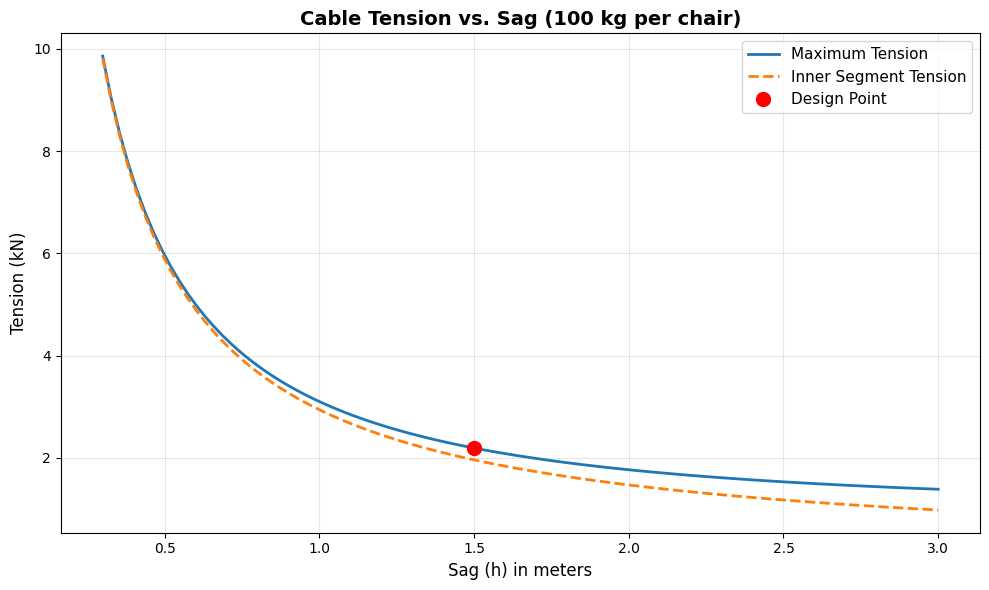

Design Parameters:
  Span: 10 m
  Chair distance from support: 3 m
  Sag: 1.5 m
  Load per chair: 0.98 kN
  Maximum tension: 2.19 kN
  Safety factor: 5
  Required chain strength: 10.97 kN

Chair Placement Analysis:
  Near edges: a=1m, T=1.18 kN
  Moderate: a=2m, T=1.64 kN
  Optimal: a=3m, T=2.19 kN
  Center: a=4m, T=2.79 kN


In [1]:
# Step 2: Import required modules and define constants
import numpy as np
import matplotlib.pyplot as plt

# Step 3: Constants
g = 9.81  # m/s²
mass_per_chair = 100  # kg (one person per chair)
W = mass_per_chair * g  # N

# Step 4: Geometry
L = 10  # Total span (m)
h = np.linspace(0.3, 3.0, 100)  # Sag range

# Step 5: Symmetric case: chairs at 3m from each support
a = 3  # Distance from support to chair (m)

# Step 6: Calculate tensions
theta = np.arctan(h / a)
T_outer = W / np.sin(theta)
T_inner = W / np.tan(theta)
T_max = T_outer

# Step 7: Plotting
plt.figure(figsize=(10, 6))
plt.plot(h, T_max/1000, linewidth=2, label='Maximum Tension')
plt.plot(h, T_inner/1000, '--', linewidth=2, label='Inner Segment Tension')

# Step 8: Add design point
design_h = 1.5
design_T = W / np.sin(np.arctan(design_h/a))
plt.plot(design_h, design_T/1000, 'ro', markersize=10, label='Design Point')

plt.xlabel('Sag (h) in meters', fontsize=12)
plt.ylabel('Tension (kN)', fontsize=12)
plt.title('Cable Tension vs. Sag (100 kg per chair)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tension_vs_sag.png', dpi=300)
plt.show()

# Step 9: Calculate required chain strength with safety factor
SF = 5
required_strength = design_T * SF

print(f"Design Parameters:")
print(f"  Span: {L} m")
print(f"  Chair distance from support: {a} m")
print(f"  Sag: {design_h} m")
print(f"  Load per chair: {W/1000:.2f} kN")
print(f"  Maximum tension: {design_T/1000:.2f} kN")
print(f"  Safety factor: {SF}")
print(f"  Required chain strength: {required_strength/1000:.2f} kN")

# Step 10: Chair placement analysis
print("\nChair Placement Analysis:")
placements = [
    (1, 8, "Near edges"),
    (2, 6, "Moderate"),
    (3, 4, "Optimal"),
    (4, 2, "Center")
]

for a_val, b_val, label in placements:
    theta_val = np.arctan(design_h / a_val)
    T = W / np.sin(theta_val)
    print(f"  {label}: a={a_val}m, T={T/1000:.2f} kN")